In [1]:
import sys
sys.path.append('../../')
from DEDi import ode_find as ode
from DEDi.ODE.PolyLib import *
import numpy as np
import matplotlib.pyplot as plt
from ODEForward.ODEFuncs import *

### Van Der Pol Oscillator
$\mu = 2$

\begin{align}
    \frac{dx}{dt} &= y \\
    \frac{dy}{dt} &= \mu(1-x^2)y - x
\end{align}

(501, 2)


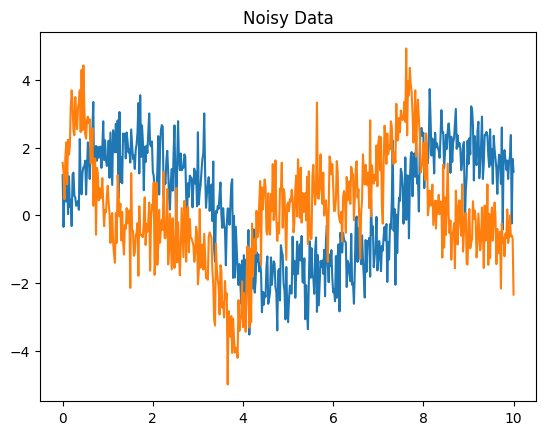

In [2]:
TSpan = (0,10)
dt = .02
x0 = [0.0,2.0]

x_data_true = vanderpolData(TSpan,dt,x0)

percent_noise = .5

noise = np.std(x_data_true,axis = 0)

np.random.seed(1)
x_data = x_data_true + np.random.normal(0,percent_noise*noise,size = x_data_true.shape)


T_grid = np.arange(TSpan[0], TSpan[1]+dt, dt)
plt.plot(T_grid,x_data)
plt.title('Noisy Data')
Name = str(percent_noise) + "Noise"
# plt.savefig('Images/VanDerPol/Orignal' + Name + '.pdf')
print(np.shape(x_data))
plt.show()


In [3]:
## If you want to mask the states
FractionOfDataMissing = 0.0
NumOfDataMissing = int(np.size(x_data)*FractionOfDataMissing)
state_mask = np.ones(np.size(x_data)).astype(bool)
state_mask[:NumOfDataMissing] = False
np.random.shuffle(state_mask)
state_mask = np.reshape(state_mask,np.shape(x_data))
x_data = x_data*state_mask #Just to show it is truly masking this data

In [4]:
Library = PolyFunc(num_vars=2,degree=3,constant=False)
print(Library)
discoverCubOsc = ode(x_data,Library,[TSpan[0],TSpan[1]],
                     state_mask = state_mask,sparse_projections=None)

['x_1', 'x_2', 'x_1 x_2', 'x_1^2', 'x_2^2', 'x_1 x_2^2', 'x_1^2 x_2', 'x_1^3', 'x_2^3']
Setting up Sparse Hessian
Colors Needed = 25


In [5]:
guess = discoverCubOsc.FindBestModel(objective_params = [1e-2,1e-4],
                                     tolerance = 1e-10,verbose=True,
                                     max_iterations = 500,method = "LM",
                                     info_criteria='BIC',
                                     drop_method = {"initial":'single',"k":3})

1 | f = 2466175.919529, ||df|| = 2.752e+05, Alpha = 2.000e+01, SolverTime = 0.028s, HessianTime = 0.003s
1 | f = 2466175.919527, ||df|| = 2.752e+05, Alpha = 2.000e+01, SolverTime = 0.042s, HessianTime = 0.002s
2 | f = 2135395.079956, ||df|| = 2.535e+05, Alpha = 4.000e+00, SolverTime = 0.002s, HessianTime = 0.002s
2 | f = 2135395.079952, ||df|| = 2.535e+05, Alpha = 4.000e+00, SolverTime = 0.001s, HessianTime = 0.002s
3 | f = 1171563.278834, ||df|| = 1.796e+05, Alpha = 8.000e-01, SolverTime = 0.002s, HessianTime = 0.002s
3 | f = 1171563.278827, ||df|| = 1.796e+05, Alpha = 8.000e-01, SolverTime = 0.001s, HessianTime = 0.002s
4 | f = 219466.763527, ||df|| = 6.420e+04, Alpha = 1.600e-01, SolverTime = 0.002s, HessianTime = 0.002s
4 | f = 219466.763518, ||df|| = 6.420e+04, Alpha = 1.600e-01, SolverTime = 0.001s, HessianTime = 0.002s
5 | f = 20159.114866, ||df|| = 1.025e+04, Alpha = 3.200e-02, SolverTime = 0.002s, HessianTime = 0.003s
5 | f = 20159.114853, ||df|| = 1.025e+04, Alpha = 3.200e-02

In [6]:
FullModels,latex_code = discoverCubOsc.PrintModels(ICCutoff=10,return_latex=True)
latex_code

<IPython.core.display.Latex object>

'\\begin{align*}Rel IC &= 0.0\\\\Likelyhood &= 5.120805884584799\\\\\\dot{x_1} &= 1.065x_2 \\\\\\dot{x_2} &= -0.925x_1 + 1.933x_2 - 1.761x_1^2 x_2 \\\\Rel IC &= 6.79\\\\Likelyhood &= 5.120199090976768\\\\\\dot{x_1} &= 1.065x_2 \\\\\\dot{x_2} &= -0.954x_1 + 1.920x_2 + 0.031x_1 x_2^2 - 1.780x_1^2 x_2 \\\\\\end{align*}'

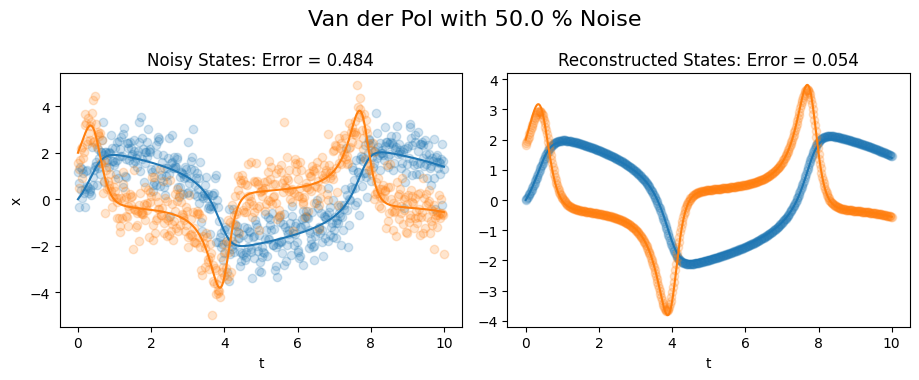

In [7]:
opt_states,opt_params = discoverCubOsc.unravel_states_and_parameters(discoverCubOsc.states_and_parameters)
state_mask = discoverCubOsc.state_mask

##Overlay
RelError_data = np.linalg.norm((x_data - x_data_true)*state_mask)/np.linalg.norm(x_data_true*state_mask)
RelError_reconstuct = np.linalg.norm((opt_states - x_data_true)*state_mask)/np.linalg.norm(x_data_true*state_mask)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns
axs[0].plot(T_grid,x_data_true,label = ['x_data','y_data'])
axs[0].scatter(T_grid,x_data[:,0],marker = 'o',alpha=.2)
axs[0].scatter(T_grid,x_data[:,1],marker = 'o',alpha=.2)
axs[0].set_title(f'Noisy States: Error = {RelError_data:.3f}')
axs[0].set_xlabel('t')
axs[0].set_ylabel('x')

axs[1].scatter(T_grid,opt_states[:,0],marker = 'o',alpha=.2)
axs[1].scatter(T_grid,opt_states[:,1],marker = 'o',alpha=.2)
axs[1].plot(T_grid,x_data_true,label = ['x_found','y_found'])
axs[1].set_title(f'Reconstructed States: Error = {RelError_reconstuct:.3f}')
axs[1].set_xlabel('t')


plt.suptitle(f'Van der Pol with {percent_noise*100} % Noise', fontsize=16)
plt.tight_layout(rect=[0.02, 0.04, .95, 1]) 
fig.show()

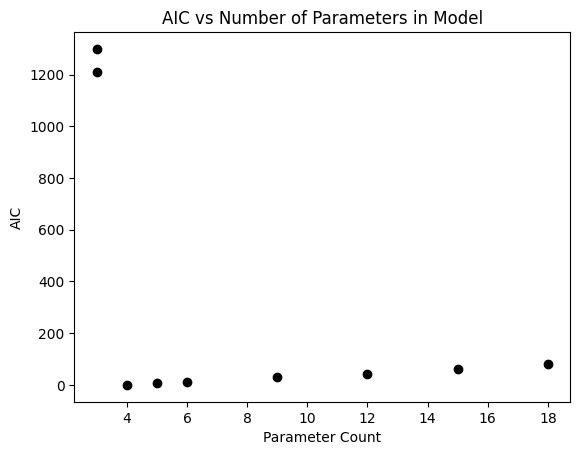

In [8]:
M,N = np.shape(FullModels)
Name = str(percent_noise) + "Noise" + str(FractionOfDataMissing) + "Missing"


for i in range(M):
    plt.scatter(np.count_nonzero(FullModels[i,2]),FullModels[i,0],c = 'black')

plt.title("AIC vs Number of Parameters in Model")
plt.xlabel("Parameter Count")
plt.ylabel("AIC")
plt.show()